In [1]:
import torch
import torchvision
import torchvision.datasets as datasets

In [2]:
mnist_datasets = datasets.MNIST(root='./data/', train=True, download=True, transform=None)

In [3]:
mnist_testset = datasets.MNIST(root='./data/', train=False, download=True, transform=None)

In [4]:
len(mnist_datasets)

60000

In [5]:
len(mnist_testset)

10000

In [6]:
import matplotlib.pyplot as plt

In [7]:
image, label = mnist_datasets[7]

<function matplotlib.pyplot.show(close=None, block=None)>

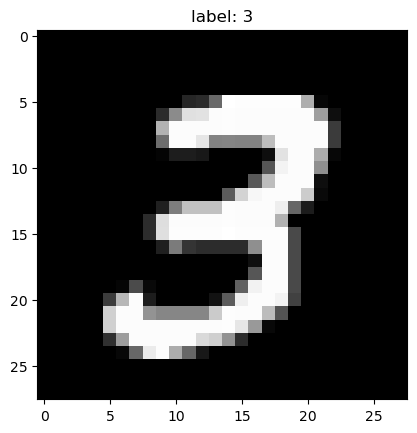

In [8]:
plt.imshow(image, cmap='gray')
plt.title(f'label: {label}')
plt.show

In [9]:
train_image_zero, train_target_zero = mnist_datasets[5]

In [36]:
train_image_zero.show()

In [11]:
print(train_target_zero)

2


## Building a Simple MNIST Classifier using pytorch

In [12]:
import torch
import torchvision
import torchvision.datasets as torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torch import nn, optim

In [30]:
# prepare the data
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.MNIST(root='./', train=True, transform=transform, download=True)
testset = torchvision.MNIST(root='./', train=False, transform=transform, download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

In [31]:
x, y = trainset[1]

<function matplotlib.pyplot.show(close=None, block=None)>

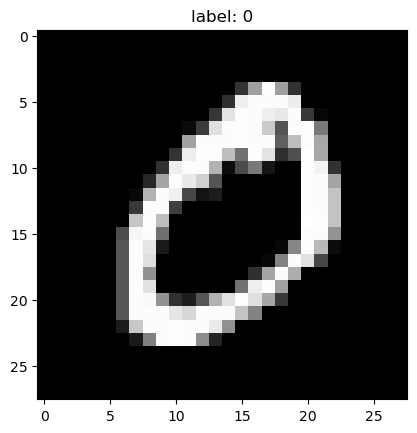

In [27]:
plt.imshow(x, cmap='gray')
plt.title(f'label: {y}')
plt.show

In [33]:
print(y)

0


In [32]:
#Build the neural network for forward feed
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(28 * 28, 512) # Hidden layer
        self.output = nn.Linear(512, 10)      # output layer
        self.sigmoid = nn.Sigmoid()           # Activation function
        self.softmax = nn.LogSoftmax(dim=1)   # Output

    def forward(self, x):
        x = self.hidden(x)
        x = self.sigmoid(x)
        x = self.output(x)
        x = self.softmax(x)
        return x

model = Net()

In [34]:
# forward pass and initial loss calculation
criterion = nn.NLLLoss() # define the loss function
images, labels = next(iter(trainloader))
images = images.view(images.shape[0], -1) # flatten the image
prediction = model(images) #forward pass
loss = criterion(prediction, labels)
print(loss)

tensor(2.3819, grad_fn=<NllLossBackward0>)
